# COMPARACIÓN FINAL — Críticos vs LLM+ROS
## Clasificación Multilabel de Patologías Cerebrales

### Estructura de la comparación

**PARTE A — Críticos (sin augmentación):**  SVM Linear, XGBoost y LSTM entrenados sobre `rad_criticos.xlsx`.
Test: **191 muestras** (split 80/20 de 952 registros, `random_state=42`).

**PARTE B — LLM+ROS (datos aumentados):**  SVM Linear, Random Forest, LSTM y DistilBERT con LLM augmentation + ROS.
Test: **143 muestras** reales (split fijo de `train_augmentado_llm.xlsx`).

| Cuaderno | Modelo | Grupo |
|---|---|---|
| `1_Modelos_Exploracion.ipynb` | SVM Linear · Random Forest | LLM+ROS |
| `2_Modelo_LSTM_Baseline.ipynb` | LSTM Bidireccional | Críticos + LLM+ROS |
| `4_Modelo_XGBoost_Balanceado.ipynb` | XGBoost | Críticos |
| `6_Modelo_Transformers.ipynb` | DistilBERT Multilingual | LLM+ROS |

> ⚠️ Los grupos usan **test sets distintos** — la comparación justa es **dentro de cada grupo**.

## 1. Importaciones y configuración

In [1]:
from dotenv import load_dotenv
import os
import re

load_dotenv()  # carga automáticamente el .env de la raíz

DATA_DIR           = os.getenv("DATA_DIR", "./data")
RAW_DATA_PATH      = os.getenv("RAW_DATA_PATH", "./data/raw/dataset.xlsx")
PROCESSED_DATA_PATH= os.getenv("PROCESSED_DATA_PATH", "./data/processed/dataset_procesado.pkl")
MODELS_DIR         = os.getenv("MODELS_DIR", "./models")
RANDOM_SEED        = int(os.getenv("RANDOM_SEED", 42))

In [2]:
# =============================================================================
# IMPORTACIONES
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Modelos
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.base import clone

# Preprocesamiento y evaluación
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    cohen_kappa_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

# Configuración visual
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

PATOLOGIAS = ['acv', 'hemorragia', 'desviacion_linea_media', 'fractura_compleja_craneo']
COLORES_MODELOS = {
    'SVM Linear':  '#3498db',
    'LSTM':        '#e74c3c',
    'XGBoost':     '#2ecc71',
    'DistilBERT':  '#9b59b6'
}

print("Librerías cargadas correctamente.")
print(f"Patologías a clasificar: {PATOLOGIAS}")


Librerías cargadas correctamente.
Patologías a clasificar: ['acv', 'hemorragia', 'desviacion_linea_media', 'fractura_compleja_craneo']


## 2. Carga de datos críticos y vectorización TF-IDF

Base común para la **PARTE A** (modelos en datos críticos).
Dataset: `rad_criticos.xlsx` · Split 80/20 · `random_state=42`

In [3]:
# =============================================================================
# CARGA DE DATOS
# =============================================================================

df = pd.read_excel('../data/rad_criticos.xlsx')

print(f"Dataset cargado: {df.shape[0]} muestras, {df.shape[1]} columnas")


Dataset cargado: 952 muestras, 15 columnas


In [4]:
# =============================================================================
# ETIQUETADO DE PATOLOGÍAS (generado automáticamente desde Hallazgos + Opinión)
# =============================================================================

def detectar_patologia_robusta(texto, keywords_positivos, keywords_negativos=None):
    """Detecta patologías con análisis de contexto robusto (ventana de negación)."""
    if not isinstance(texto, str):
        return 0
    texto = texto.lower()
    keywords_negativos = keywords_negativos or [
        'antiguo','antigua','cronico','cronica','crónico','crónica',
        'viejo','vieja','residual','residuales','secuela','secuelar','secuelas',
        'previo','previa','previos','previas','conocido','conocida',
        'sin cambios','estable','estables','resolucion','resolución'
    ]
    negaciones_contextuales = [
        'sin','descarta','descartado','descartada','negativo','negativa',
        'ausencia','ausente','ausentes','sin evidencia','sin signos',
        'no se observa','no se observan','no se evidencia','no se evidencian',
        'no se identifica','no se identifican','libre de',
        'negativo para','negativa para'
    ]
    keywords_ordenadas = sorted(keywords_positivos, key=len, reverse=True)
    oraciones = re.split(r'[.;]', texto)
    for oracion in oraciones:
        oracion = oracion.strip()
        keyword_encontrada = next((kw for kw in keywords_ordenadas if kw in oracion), None)
        if not keyword_encontrada:
            continue
        if re.search(re.escape(keyword_encontrada) + r'\s*:\s*no\b', oracion):
            continue
        if re.search(re.escape(keyword_encontrada) + r'\s*:[^.;]*?\b(no|negativo|negativa|ausente)\b', oracion):
            continue
        idx_kw = oracion.find(keyword_encontrada)
        segmento_previo = oracion[max(0, idx_kw-50):idx_kw]
        if any(neg in segmento_previo for neg in negaciones_contextuales):
            continue
        if re.search(r'sin\s+(hallazgos?|evidencia|signos?)\s+(indirectos?\s+)?(de\s+)?' + re.escape(keyword_encontrada), oracion):
            continue
        if any(ant in oracion for ant in keywords_negativos):
            continue
        if 'ya conocido' in oracion or 'ya conocida' in oracion:
            continue
        if 'sin cambios' in oracion:
            continue
        if 'resolucion' in oracion or 'resolución' in oracion:
            continue
        return 1
    return 0

texto_etiquetado = df['Hallazgos'] + ' ' + df['Opinión']

keywords = {
    'acv': [
        'infarto cerebral','infarto isquemico','accidente cerebrovascular',
        'hipodensidad sugestiva de isquemia','zona de isquemia',
        'area de isquemia','evento isquemico','ictus','acv','isquemia'
    ],
    'hemorragia': [
        'hemorragia subaracnoidea','hemorragia intraparenquimatosa',
        'hemorragia intraventricular','hematoma subdural','hematoma epidural',
        'hematoma intraparenquimatoso','sangrado intraparenquimatoso',
        'coleccion hematica','hemorragia','hematoma','sangrado'
    ],
    'desviacion_linea_media': [
        'desviacion de la linea media','desviacion linea media','linea media desplazada',
        'desplazamiento de la linea media','efecto de masa con desviacion',
        'shift de linea media','herniacion subfalcina','hernia subfalcina'
    ],
    'fractura_compleja_craneo': [
        'fractura con hundimiento','fractura hundimiento','fractura deprimida',
        'fractura conminuta','fractura compleja','fractura de base de craneo',
        'fractura craneofacial','fractura multiple de craneo'
    ]
}

for pat, kws in keywords.items():
    df[pat] = texto_etiquetado.apply(lambda t: detectar_patologia_robusta(t, kws))

print("Distribución de etiquetas generadas:")
for p in ['acv', 'hemorragia', 'desviacion_linea_media', 'fractura_compleja_craneo']:
    n = df[p].sum()
    print(f"  {p:12s}: {n:5d}  ({100*n/len(df):.1f}%)")


Distribución de etiquetas generadas:
  acv         :   323  (33.9%)
  hemorragia  :   813  (85.4%)
  desviacion_linea_media:   129  (13.6%)
  fractura_compleja_craneo:    30  (3.2%)


In [5]:
# =============================================================================
# DISTRIBUCIÓN + SPLIT + VECTORIZACIÓN TF-IDF
# =============================================================================

print("\nDistribución de clases generadas (positivos):")
for pat in PATOLOGIAS:
    n_pos = df[pat].sum()
    print(f"  {pat:12s}: {n_pos:4d} positivos ({n_pos/len(df)*100:.1f}%)")

X_text = df['Hallazgos'].astype(str)
y = df[PATOLOGIAS].values

# Split estratificado 80/20 — idéntico al de los cuadernos originales
X_text_train, X_text_test, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.2,
    random_state=42,
    stratify=df[PATOLOGIAS[0]].values
)

print(f"\nTrain: {len(X_text_train)} muestras | Test: {len(X_text_test)} muestras")

# Vectorización TF-IDF — misma configuración que cuadernos 2 y 5
stopwords_es = ['de','la','y','el','en','del','con','se','las','los','por','para',
                'al','lo','un','una','es','su','sus','que','a','o','sin','no',
                'izquierdo','izquierda','derecha','derecho','mm']

vectorizer = TfidfVectorizer(
    max_features=200,
    min_df=5,
    max_df=0.8,
    ngram_range=(1, 2),
    stop_words=stopwords_es
)

X_train = vectorizer.fit_transform(X_text_train)
X_test  = vectorizer.transform(X_text_test)

print(f"TF-IDF: {X_train.shape[1]} features")



Distribución de clases generadas (positivos):
  acv         :  323 positivos (33.9%)
  hemorragia  :  813 positivos (85.4%)
  desviacion_linea_media:  129 positivos (13.6%)
  fractura_compleja_craneo:   30 positivos (3.2%)

Train: 761 muestras | Test: 191 muestras
TF-IDF: 200 features


---
## PARTE A — Modelos entrenados en datos Críticos

Dataset: `rad_criticos.xlsx` · Sin augmentación · Test: **191 muestras** (20% de 952)

| Modelo | Tipo | Fuente |
|---|---|---|
| **SVM Linear** | TF-IDF + LinearSVC, `class_weight='balanced'` | Cuaderno 1 |
| **XGBoost** | TF-IDF + XGBClassifier, `scale_pos_weight` | Cuaderno 4 |
| **LSTM Bidireccional** | Embedding + Red recurrente | Cuaderno 2 |

### A1. SVM Linear (Críticos)
Configuración: `class_weight='balanced'`, `max_iter=1000`, `random_state=42`.

In [6]:
# =============================================================================
# SVM LINEAR — configuración idéntica al cuaderno 1
# Entrenado en datos críticos (rad_criticos.xlsx, split 80/20)
# =============================================================================

print("=" * 70)
print("ENTRENAMIENTO: SVM LINEAR (Críticos)")
print("=" * 70)

svm_base = LinearSVC(class_weight='balanced', max_iter=1000, random_state=42)

resultados_svm = []
predicciones_svm = {}

for idx, pat in enumerate(PATOLOGIAS):
    y_train_pat = y_train[:, idx]
    y_test_pat  = y_test[:, idx]

    modelo = clone(svm_base)
    modelo.fit(X_train, y_train_pat)
    y_pred = modelo.predict(X_test)

    precision = precision_score(y_test_pat, y_pred, zero_division=0)
    recall    = recall_score(y_test_pat, y_pred, zero_division=0)
    f1        = f1_score(y_test_pat, y_pred, zero_division=0)
    kappa     = cohen_kappa_score(y_test_pat, y_pred)

    predicciones_svm[pat] = {'y_test': y_test_pat, 'y_pred': y_pred}
    resultados_svm.append({
        'Patología': pat,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Kappa': kappa
    })
    print(f"  {pat:30s} → F1: {f1:.3f} | Recall: {recall:.3f} | Precision: {precision:.3f} | Kappa: {kappa:.3f}")

f1_macro_svm        = np.mean([r['F1']       for r in resultados_svm])
recall_macro_svm    = np.mean([r['Recall']   for r in resultados_svm])
precision_macro_svm = np.mean([r['Precision']for r in resultados_svm])
kappa_macro_svm     = np.mean([r['Kappa']    for r in resultados_svm])

print(f"\n{'─'*60}")
print(f"  {'MACRO':30s} → F1: {f1_macro_svm:.3f} | Recall: {recall_macro_svm:.3f} | "
      f"Precision: {precision_macro_svm:.3f} | Kappa: {kappa_macro_svm:.3f}")

ENTRENAMIENTO: SVM LINEAR (Críticos)
  acv                            → F1: 0.935 | Recall: 0.892 | Precision: 0.983 | Kappa: 0.905
  hemorragia                     → F1: 0.940 | Recall: 0.903 | Precision: 0.980 | Kappa: 0.651
  desviacion_linea_media         → F1: 0.473 | Recall: 0.619 | Precision: 0.382 | Kappa: 0.390
  fractura_compleja_craneo       → F1: 0.333 | Recall: 0.444 | Precision: 0.267 | Kappa: 0.292

────────────────────────────────────────────────────────────
  MACRO                          → F1: 0.670 | Recall: 0.715 | Precision: 0.653 | Kappa: 0.559


### A2. XGBoost (Críticos)
Configuración: `scale_pos_weight` calculado por patología desde el conjunto de entrenamiento, `n_estimators=100`, `max_depth=6`.

In [7]:
# =============================================================================
# XGBOOST CON scale_pos_weight — configuración idéntica al cuaderno 4
# =============================================================================

print("=" * 70)
print("ENTRENAMIENTO: XGBoost (scale_pos_weight)")
print("=" * 70)

resultados_xgb = []
predicciones_xgb = {}

for idx, pat in enumerate(PATOLOGIAS):
    y_train_pat = y_train[:, idx]
    y_test_pat  = y_test[:, idx]
    
    # scale_pos_weight calculado solo desde train
    n_pos = y_train_pat.sum()
    n_neg = len(y_train_pat) - n_pos
    spw   = n_neg / n_pos
    
    modelo = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.3,
        scale_pos_weight=spw,
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1
    )
    modelo.fit(X_train, y_train_pat)
    y_pred = modelo.predict(X_test)
    
    precision = precision_score(y_test_pat, y_pred, zero_division=0)
    recall    = recall_score(y_test_pat, y_pred, zero_division=0)
    f1        = f1_score(y_test_pat, y_pred, zero_division=0)
    kappa     = cohen_kappa_score(y_test_pat, y_pred)
    
    predicciones_xgb[pat] = {'y_test': y_test_pat, 'y_pred': y_pred}
    resultados_xgb.append({
        'Patología': pat,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Kappa': kappa
    })
    print(f"  {pat:12s} → F1: {f1:.3f} | Recall: {recall:.3f} | Precision: {precision:.3f} | Kappa: {kappa:.3f} [SPW={spw:.2f}]")

f1_macro_xgb        = np.mean([r['F1'] for r in resultados_xgb])
recall_macro_xgb    = np.mean([r['Recall'] for r in resultados_xgb])
precision_macro_xgb = np.mean([r['Precision'] for r in resultados_xgb])
kappa_macro_xgb     = np.mean([r['Kappa'] for r in resultados_xgb])

print(f"\n{'─'*50}")
print(f"  {'MACRO':12s} → F1: {f1_macro_xgb:.3f} | Recall: {recall_macro_xgb:.3f} | "
      f"Precision: {precision_macro_xgb:.3f} | Kappa: {kappa_macro_xgb:.3f}")


ENTRENAMIENTO: XGBoost (scale_pos_weight)
  acv          → F1: 0.943 | Recall: 0.892 | Precision: 1.000 | Kappa: 0.916 [SPW=1.95]
  hemorragia   → F1: 0.960 | Recall: 0.958 | Precision: 0.963 | Kappa: 0.715 [SPW=0.17]
  desviacion_linea_media → F1: 0.595 | Recall: 0.524 | Precision: 0.688 | Kappa: 0.552 [SPW=6.05]
  fractura_compleja_craneo → F1: 0.462 | Recall: 0.333 | Precision: 0.750 | Kappa: 0.445 [SPW=35.24]

──────────────────────────────────────────────────
  MACRO        → F1: 0.740 | Recall: 0.677 | Precision: 0.850 | Kappa: 0.657


### A3. LSTM Bidireccional (Críticos)
Valores reportados del cuaderno `2_Modelo_LSTM_Baseline.ipynb` — entrenamiento sobre datos críticos sin augmentación.
Arquitectura: `Embedding → SpatialDropout(0.2) → BiLSTM(64) → BiLSTM(32) → Dense(1, sigmoid)` · Umbral óptimo por curva Precision-Recall · Early stopping patience=4.

In [8]:
# =============================================================================
# LSTM BIDIRECCIONAL — DATOS CRÍTICOS (cuaderno 2)
# Test set: 191 muestras (mismo split 80/20 desde rad_criticos.xlsx, random_state=42)
# =============================================================================

resultados_lstm_criticos = {
    'acv':                     {'AUC': 0.935, 'F1_pos': 0.882, 'F1_neg': 0.922, 'Kappa': 0.805},
    'hemorragia':              {'AUC': 0.878, 'F1_pos': 0.922, 'F1_neg': 0.480, 'Kappa': 0.419},
    'desviacion_linea_media':  {'AUC': 0.708, 'F1_pos': 0.196, 'F1_neg': 0.667, 'Kappa': 0.095},
    'fractura_compleja_craneo':{'AUC': 0.796, 'F1_pos': 0.500, 'F1_neg': 0.995, 'Kappa': 0.495},
}

f1_macro_lstm_crit    = np.mean([v['F1_pos'] for v in resultados_lstm_criticos.values()])
auc_macro_lstm_crit   = np.mean([v['AUC']    for v in resultados_lstm_criticos.values()])
kappa_macro_lstm_crit = np.mean([v['Kappa']  for v in resultados_lstm_criticos.values()])

print('LSTM Bidireccional — Datos Críticos (cuaderno 2):')
print(f"{'Patología':<30} {'AUC':>8} {'F1-Pos':>10} {'F1-Neg':>10} {'Kappa':>8}")
print('-' * 62)
for pat in PATOLOGIAS:
    v = resultados_lstm_criticos[pat]
    print(f"{pat:<30} {v['AUC']:>8.3f} {v['F1_pos']:>10.3f} {v['F1_neg']:>10.3f} {v['Kappa']:>8.3f}")
print('=' * 62)
print(f"{'AUC Macro':<30} {auc_macro_lstm_crit:>8.3f}")
print(f"{'F1-Pos Macro':<30} {'':>8} {f1_macro_lstm_crit:>10.3f}")
print(f"{'Kappa Macro':<30} {'':>8} {'':>10} {'':>10} {kappa_macro_lstm_crit:>8.3f}")

# =============================================================================
# TABLA COMPARATIVA — PARTE A: Críticos
# =============================================================================

df_svm_crit = pd.DataFrame(resultados_svm).set_index('Patología')
df_xgb_crit = pd.DataFrame(resultados_xgb).set_index('Patología')

print('\n' + '=' * 90)
print('TABLA COMPARATIVA — PARTE A: Críticos')
print('Dataset: rad_criticos.xlsx  ·  Test: 191 muestras  ·  Sin augmentación')
print('=' * 90)

tabla_a_f1 = pd.DataFrame({
    'SVM Linear':      [df_svm_crit.loc[p, 'F1']             for p in PATOLOGIAS],
    'XGBoost':         [df_xgb_crit.loc[p, 'F1']             for p in PATOLOGIAS],
    'LSTM (Críticos)': [resultados_lstm_criticos[p]['F1_pos'] for p in PATOLOGIAS],
}, index=PATOLOGIAS)

tabla_a_kappa = pd.DataFrame({
    'SVM Linear':      [df_svm_crit.loc[p, 'Kappa']          for p in PATOLOGIAS],
    'XGBoost':         [df_xgb_crit.loc[p, 'Kappa']          for p in PATOLOGIAS],
    'LSTM (Críticos)': [resultados_lstm_criticos[p]['Kappa']  for p in PATOLOGIAS],
}, index=PATOLOGIAS)

print('\nF1-Score (clase positiva):')
print(tabla_a_f1.round(3).to_string())
print("\nCohen's Kappa:")
print(tabla_a_kappa.round(3).to_string())

tabla_a_macro = pd.DataFrame([
    {'Modelo': 'SVM Linear',         'F1-Macro': f1_macro_svm,
     'Kappa-Macro': kappa_macro_svm, 'AUC-Macro': float('nan')},
    {'Modelo': 'XGBoost',            'F1-Macro': f1_macro_xgb,
     'Kappa-Macro': kappa_macro_xgb, 'AUC-Macro': float('nan')},
    {'Modelo': 'LSTM Bidireccional', 'F1-Macro': f1_macro_lstm_crit,
     'Kappa-Macro': kappa_macro_lstm_crit, 'AUC-Macro': auc_macro_lstm_crit},
]).set_index('Modelo')

print('\nMétricas Macro — PARTE A:')
print(tabla_a_macro.round(3).to_string())

print('\nMejor F1-pos por patología (Críticos):')
for pat in PATOLOGIAS:
    vals = {
        'SVM':     df_svm_crit.loc[pat, 'F1'],
        'XGBoost': df_xgb_crit.loc[pat, 'F1'],
        'LSTM':    resultados_lstm_criticos[pat]['F1_pos'],
    }
    mejor = max(vals, key=vals.get)
    print(f"  {pat:<30} → {mejor} ({vals[mejor]:.3f})")

LSTM Bidireccional — Datos Críticos (cuaderno 2):
Patología                           AUC     F1-Pos     F1-Neg    Kappa
--------------------------------------------------------------
acv                               0.935      0.882      0.922    0.805
hemorragia                        0.878      0.922      0.480    0.419
desviacion_linea_media            0.708      0.196      0.667    0.095
fractura_compleja_craneo          0.796      0.500      0.995    0.495
AUC Macro                         0.829
F1-Pos Macro                                 0.625
Kappa Macro                                                      0.454

TABLA COMPARATIVA — PARTE A: Críticos
Dataset: rad_criticos.xlsx  ·  Test: 191 muestras  ·  Sin augmentación

F1-Score (clase positiva):
                          SVM Linear  XGBoost  LSTM (Críticos)
acv                           0.9350   0.9430           0.8820
hemorragia                    0.9400   0.9600           0.9220
desviacion_linea_media        0.4730   0.59

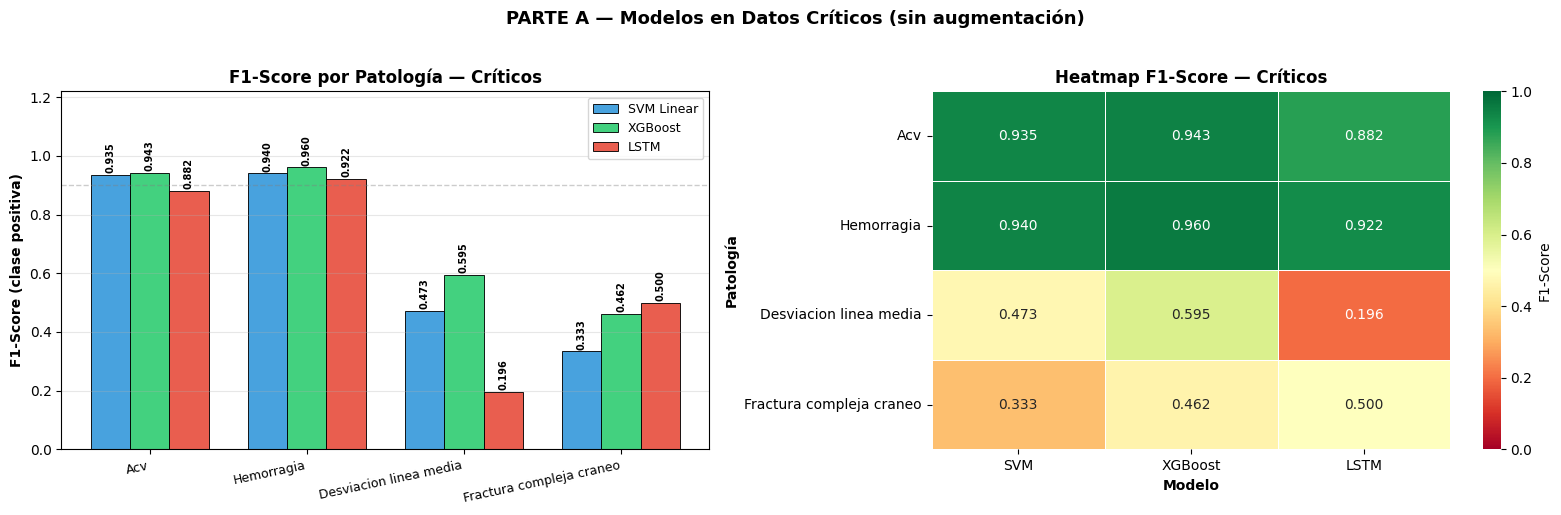

In [9]:
# =============================================================================
# VISUALIZACIONES — PARTE A: Críticos
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x     = np.arange(len(PATOLOGIAS))
width = 0.25

vals_a_svm  = [df_svm_crit.loc[p, 'F1']             for p in PATOLOGIAS]
vals_a_xgb  = [df_xgb_crit.loc[p, 'F1']             for p in PATOLOGIAS]
vals_a_lstm = [resultados_lstm_criticos[p]['F1_pos'] for p in PATOLOGIAS]

b1 = axes[0].bar(x - width, vals_a_svm,  width, label='SVM Linear', color='#3498db', alpha=0.9, edgecolor='black', lw=0.7)
b2 = axes[0].bar(x,          vals_a_xgb,  width, label='XGBoost',   color='#2ecc71', alpha=0.9, edgecolor='black', lw=0.7)
b3 = axes[0].bar(x + width,  vals_a_lstm, width, label='LSTM',      color='#e74c3c', alpha=0.9, edgecolor='black', lw=0.7)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                     f'{h:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold', rotation=90)

axes[0].set_xticks(x)
axes[0].set_xticklabels([p.replace('_', ' ').capitalize() for p in PATOLOGIAS],
                         fontsize=9, rotation=12, ha='right')
axes[0].set_ylabel('F1-Score (clase positiva)', fontweight='bold')
axes[0].set_title('F1-Score por Patología — Críticos', fontweight='bold')
axes[0].set_ylim([0.0, 1.22])
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)
axes[0].axhline(y=0.9, color='gray', linestyle='--', alpha=0.4, lw=1)

heatmap_a = pd.DataFrame({
    'SVM':     vals_a_svm,
    'XGBoost': vals_a_xgb,
    'LSTM':    vals_a_lstm,
}, index=[p.replace('_', ' ').capitalize() for p in PATOLOGIAS])

sns.heatmap(heatmap_a, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.0, vmax=1.0, ax=axes[1],
            cbar_kws={'label': 'F1-Score'},
            linewidths=0.5, linecolor='white')
axes[1].set_title('Heatmap F1-Score — Críticos', fontweight='bold')
axes[1].set_xlabel('Modelo', fontweight='bold')
axes[1].set_ylabel('Patología', fontweight='bold')

plt.suptitle('PARTE A — Modelos en Datos Críticos (sin augmentación)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/comparacion_parte_a_criticos.png', dpi=150, bbox_inches='tight')
plt.show()

---
## PARTE B — Modelos con LLM+ROS (datos aumentados)

Dataset: `train_augmentado_llm.xlsx` · LLM augmentation + Random Oversampling · Test: **143 muestras** reales

| Modelo | Tipo | Fuente |
|---|---|---|
| **SVM Linear** (LLM+ROS) | TF-IDF + LinearSVC | Cuaderno 1 |
| **Random Forest** (LLM+ROS) | TF-IDF + Ensemble | Cuaderno 1 |
| **LSTM** (LLM+ROS) | Embedding + Red recurrente | Cuaderno 2, escenario LLM+ROS |
| **DistilBERT Multilingual** | Transformer fine-tuning, 3 épocas | Cuaderno 6 |

Todos los resultados son **valores reportados** de los cuadernos correspondientes.
Test set idéntico para los cuatro modelos: 143 muestras reales (split fijo).

In [10]:
# =============================================================================
# RESULTADOS REPORTADOS — LLM+ROS
# Fuentes: cuaderno 1 (SVM/RF), cuaderno 2 (LSTM), cuaderno 6 (DistilBERT)
# Test set: 143 muestras reales (split fijo train_augmentado_llm.xlsx)
# =============================================================================

# SVM Linear (LLM+ROS) — cuaderno 1, mejor configuración
res_svm_llm = {
    'acv':                     {'F1': 0.966, 'Recall': 0.935, 'Precision': 1.000},
    'hemorragia':              {'F1': 0.948, 'Recall': 0.944, 'Precision': 0.952},
    'desviacion_linea_media':  {'F1': 0.927, 'Recall': 0.864, 'Precision': 1.000},
    'fractura_compleja_craneo':{'F1': 0.750, 'Recall': 0.600, 'Precision': 1.000},
}

# Random Forest (LLM+ROS) — cuaderno 1
res_rf_llm = {
    'acv':                     {'F1': 0.989, 'Recall': 0.978, 'Precision': 1.000},
    'hemorragia':              {'F1': 0.946, 'Recall': 0.968, 'Precision': 0.924},
    'desviacion_linea_media':  {'F1': 0.872, 'Recall': 0.773, 'Precision': 1.000},
    'fractura_compleja_craneo':{'F1': 0.750, 'Recall': 0.600, 'Precision': 1.000},
}

# LSTM Bidireccional (LLM+ROS) — cuaderno 2, escenario LLM+ROS (boost ACV con ROS)
res_lstm_llm = {
    'acv':                     {'AUC': 0.963, 'F1_pos': 0.943, 'F1_neg': 0.975, 'Kappa': 0.918},
    'hemorragia':              {'AUC': 0.784, 'F1_pos': 0.944, 'F1_neg': 0.211, 'Kappa': 0.190},
    'desviacion_linea_media':  {'AUC': 0.792, 'F1_pos': 0.522, 'F1_neg': 0.908, 'Kappa': 0.430},
    'fractura_compleja_craneo':{'AUC': 0.870, 'F1_pos': 0.333, 'F1_neg': 0.986, 'Kappa': 0.325},
}

# DistilBERT Multilingual (LLM+ROS) — cuaderno 6, 3 épocas, class_weight balanced
res_distilbert_llm = {
    'acv':                     {'AUC': 0.976, 'F1_pos': 0.899, 'F1_neg': 0.954, 'Kappa': 0.853},
    'hemorragia':              {'AUC': 0.856, 'F1_pos': 0.958, 'F1_neg': 0.560, 'Kappa': 0.524},
    'desviacion_linea_media':  {'AUC': 0.895, 'F1_pos': 0.593, 'F1_neg': 0.905, 'Kappa': 0.502},
    'fractura_compleja_craneo':{'AUC': 0.941, 'F1_pos': 0.500, 'F1_neg': 0.986, 'Kappa': 0.487},
}

# ---- Métricas macro ----
f1_macro_svm_llm     = np.mean([v['F1']     for v in res_svm_llm.values()])
f1_macro_rf_llm      = np.mean([v['F1']     for v in res_rf_llm.values()])
f1_macro_lstm_llm    = np.mean([v['F1_pos'] for v in res_lstm_llm.values()])
f1_macro_dbt_llm     = np.mean([v['F1_pos'] for v in res_distilbert_llm.values()])
auc_macro_lstm_llm   = np.mean([v['AUC']    for v in res_lstm_llm.values()])
auc_macro_dbt_llm    = np.mean([v['AUC']    for v in res_distilbert_llm.values()])
kappa_macro_lstm_llm = np.mean([v['Kappa']  for v in res_lstm_llm.values()])
kappa_macro_dbt_llm  = np.mean([v['Kappa']  for v in res_distilbert_llm.values()])

# ---- Tabla por patología ----
print('=' * 100)
print('TABLA COMPARATIVA — PARTE B: LLM+ROS')
print('Dataset: train_augmentado_llm.xlsx  ·  Test: 143 muestras reales')
print('=' * 100)

tabla_b_f1 = pd.DataFrame({
    'SVM (LLM+ROS)':  [res_svm_llm[p]['F1']       for p in PATOLOGIAS],
    'RF (LLM+ROS)':   [res_rf_llm[p]['F1']        for p in PATOLOGIAS],
    'LSTM (LLM+ROS)': [res_lstm_llm[p]['F1_pos']  for p in PATOLOGIAS],
    'DistilBERT':     [res_distilbert_llm[p]['F1_pos'] for p in PATOLOGIAS],
}, index=PATOLOGIAS)

tabla_b_kappa = pd.DataFrame({
    'LSTM (LLM+ROS)': [res_lstm_llm[p]['Kappa']       for p in PATOLOGIAS],
    'DistilBERT':     [res_distilbert_llm[p]['Kappa']  for p in PATOLOGIAS],
}, index=PATOLOGIAS)

tabla_b_auc = pd.DataFrame({
    'LSTM (LLM+ROS)': [res_lstm_llm[p]['AUC']       for p in PATOLOGIAS],
    'DistilBERT':     [res_distilbert_llm[p]['AUC']  for p in PATOLOGIAS],
}, index=PATOLOGIAS)

print('\nF1-Score (clase positiva):')
print(tabla_b_f1.round(3).to_string())
print("\nCohen's Kappa:")
print(tabla_b_kappa.round(3).to_string())
print('\nAUC-ROC:')
print(tabla_b_auc.round(3).to_string())

tabla_b_macro = pd.DataFrame([
    {'Modelo': 'SVM Linear (LLM+ROS)',    'F1-Macro': f1_macro_svm_llm,
     'Kappa-Macro': float('nan'), 'AUC-Macro': float('nan')},
    {'Modelo': 'Random Forest (LLM+ROS)', 'F1-Macro': f1_macro_rf_llm,
     'Kappa-Macro': float('nan'), 'AUC-Macro': float('nan')},
    {'Modelo': 'LSTM (LLM+ROS)',          'F1-Macro': f1_macro_lstm_llm,
     'Kappa-Macro': kappa_macro_lstm_llm, 'AUC-Macro': auc_macro_lstm_llm},
    {'Modelo': 'DistilBERT Multilingual', 'F1-Macro': f1_macro_dbt_llm,
     'Kappa-Macro': kappa_macro_dbt_llm,  'AUC-Macro': auc_macro_dbt_llm},
]).set_index('Modelo')

print('\nMétricas Macro — PARTE B:')
print(tabla_b_macro.round(3).to_string())

print('\nMejor F1-pos por patología (LLM+ROS):')
for pat in PATOLOGIAS:
    vals = {
        'SVM':        res_svm_llm[pat]['F1'],
        'RF':         res_rf_llm[pat]['F1'],
        'LSTM':       res_lstm_llm[pat]['F1_pos'],
        'DistilBERT': res_distilbert_llm[pat]['F1_pos'],
    }
    mejor = max(vals, key=vals.get)
    print(f"  {pat:<30} → {mejor} ({vals[mejor]:.3f})")

TABLA COMPARATIVA — PARTE B: LLM+ROS
Dataset: train_augmentado_llm.xlsx  ·  Test: 143 muestras reales

F1-Score (clase positiva):
                          SVM (LLM+ROS)  RF (LLM+ROS)  LSTM (LLM+ROS)  DistilBERT
acv                              0.9660        0.9890          0.9430      0.8990
hemorragia                       0.9480        0.9460          0.9440      0.9580
desviacion_linea_media           0.9270        0.8720          0.5220      0.5930
fractura_compleja_craneo         0.7500        0.7500          0.3330      0.5000

Cohen's Kappa:
                          LSTM (LLM+ROS)  DistilBERT
acv                               0.9180      0.8530
hemorragia                        0.1900      0.5240
desviacion_linea_media            0.4300      0.5020
fractura_compleja_craneo          0.3250      0.4870

AUC-ROC:
                          LSTM (LLM+ROS)  DistilBERT
acv                               0.9630      0.9760
hemorragia                        0.7840      0.8560
desviacion

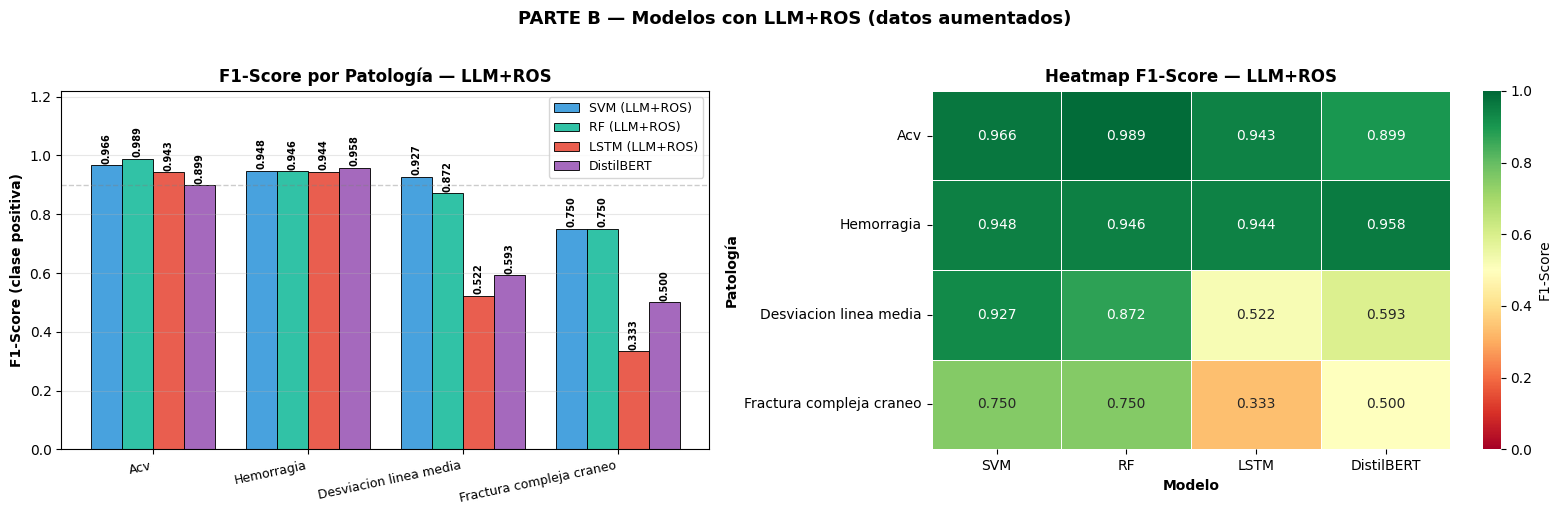

In [11]:
# =============================================================================
# VISUALIZACIONES — PARTE B: LLM+ROS
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x     = np.arange(len(PATOLOGIAS))
width = 0.20

vals_b_svm  = [res_svm_llm[p]['F1']       for p in PATOLOGIAS]
vals_b_rf   = [res_rf_llm[p]['F1']        for p in PATOLOGIAS]
vals_b_lstm = [res_lstm_llm[p]['F1_pos']  for p in PATOLOGIAS]
vals_b_dbt  = [res_distilbert_llm[p]['F1_pos'] for p in PATOLOGIAS]

b1 = axes[0].bar(x - 1.5*width, vals_b_svm,  width, label='SVM (LLM+ROS)',  color='#3498db', alpha=0.9, edgecolor='black', lw=0.7)
b2 = axes[0].bar(x - 0.5*width, vals_b_rf,   width, label='RF (LLM+ROS)',   color='#1abc9c', alpha=0.9, edgecolor='black', lw=0.7)
b3 = axes[0].bar(x + 0.5*width, vals_b_lstm, width, label='LSTM (LLM+ROS)', color='#e74c3c', alpha=0.9, edgecolor='black', lw=0.7)
b4 = axes[0].bar(x + 1.5*width, vals_b_dbt,  width, label='DistilBERT',     color='#9b59b6', alpha=0.9, edgecolor='black', lw=0.7)

for bars in [b1, b2, b3, b4]:
    for bar in bars:
        h = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                     f'{h:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold', rotation=90)

axes[0].set_xticks(x)
axes[0].set_xticklabels([p.replace('_', ' ').capitalize() for p in PATOLOGIAS],
                         fontsize=9, rotation=12, ha='right')
axes[0].set_ylabel('F1-Score (clase positiva)', fontweight='bold')
axes[0].set_title('F1-Score por Patología — LLM+ROS', fontweight='bold')
axes[0].set_ylim([0.0, 1.22])
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)
axes[0].axhline(y=0.9, color='gray', linestyle='--', alpha=0.4, lw=1)

heatmap_b = pd.DataFrame({
    'SVM':       vals_b_svm,
    'RF':        vals_b_rf,
    'LSTM':      vals_b_lstm,
    'DistilBERT':vals_b_dbt,
}, index=[p.replace('_', ' ').capitalize() for p in PATOLOGIAS])

sns.heatmap(heatmap_b, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.0, vmax=1.0, ax=axes[1],
            cbar_kws={'label': 'F1-Score'},
            linewidths=0.5, linecolor='white')
axes[1].set_title('Heatmap F1-Score — LLM+ROS', fontweight='bold')
axes[1].set_xlabel('Modelo', fontweight='bold')
axes[1].set_ylabel('Patología', fontweight='bold')

plt.suptitle('PARTE B — Modelos con LLM+ROS (datos aumentados)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/comparacion_parte_b_llm_ros.png', dpi=150, bbox_inches='tight')
plt.show()

RESUMEN — Mejor modelo de cada grupo (F1-Macro)
                        Mejor modelo  F1-Macro  Kappa-Macro  AUC-Macro                                 Nota
Grupo                                                                                                      
A — Críticos (test=191)      XGBoost    0.7400       0.6570     0.8290          AUC solo disponible en LSTM
B — LLM+ROS (test=143)           SVM    0.8980       0.5920     0.9170  Kappa/AUC solo en LSTM y DistilBERT


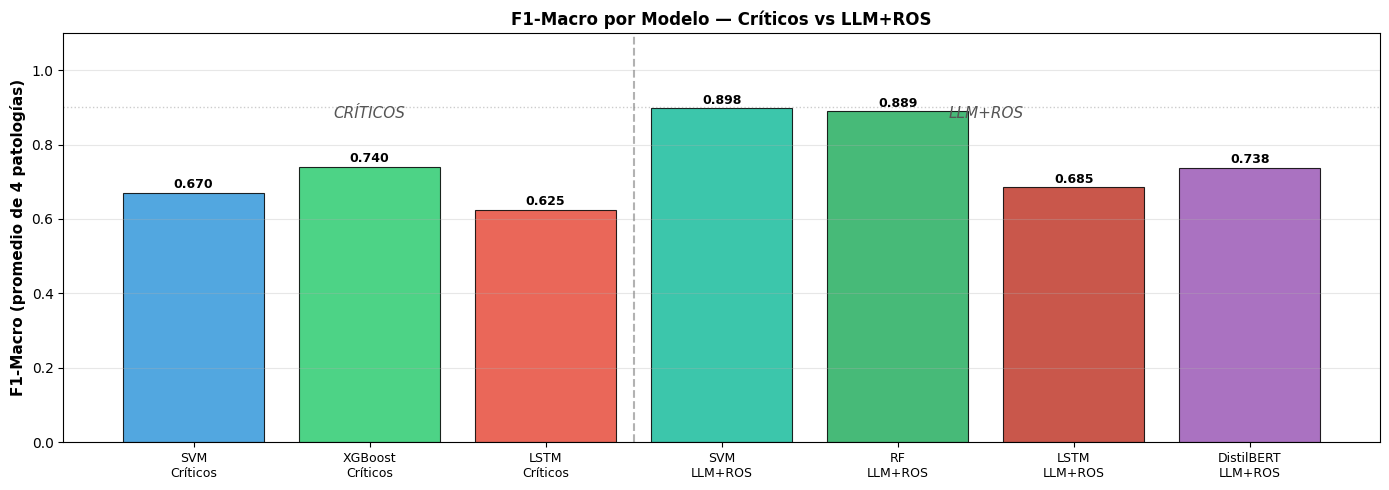

In [12]:
# =============================================================================
# RESUMEN COMPARATIVO: Críticos vs LLM+ROS
# Referencia orientativa — los grupos usan test sets distintos
# =============================================================================

print('=' * 90)
print('RESUMEN — Mejor modelo de cada grupo (F1-Macro)')
print('=' * 90)

mejor_crit = max(
    [('SVM Linear', f1_macro_svm), ('XGBoost', f1_macro_xgb), ('LSTM', f1_macro_lstm_crit)],
    key=lambda x: x[1]
)
mejor_llm = max(
    [('SVM', f1_macro_svm_llm), ('RF', f1_macro_rf_llm),
     ('LSTM', f1_macro_lstm_llm), ('DistilBERT', f1_macro_dbt_llm)],
    key=lambda x: x[1]
)

resumen = pd.DataFrame([
    {'Grupo':         'A — Críticos (test=191)',
     'Mejor modelo':  mejor_crit[0],
     'F1-Macro':      round(mejor_crit[1], 3),
     'Kappa-Macro':   round(max(kappa_macro_svm, kappa_macro_xgb, kappa_macro_lstm_crit), 3),
     'AUC-Macro':     round(auc_macro_lstm_crit, 3),
     'Nota':          'AUC solo disponible en LSTM'},
    {'Grupo':         'B — LLM+ROS (test=143)',
     'Mejor modelo':  mejor_llm[0],
     'F1-Macro':      round(mejor_llm[1], 3),
     'Kappa-Macro':   round(max(kappa_macro_lstm_llm, kappa_macro_dbt_llm), 3),
     'AUC-Macro':     round(max(auc_macro_lstm_llm, auc_macro_dbt_llm), 3),
     'Nota':          'Kappa/AUC solo en LSTM y DistilBERT'},
]).set_index('Grupo')

print(resumen.to_string())

# Gráfico de barras: F1-Macro de todos los modelos agrupados por grupo
fig, ax = plt.subplots(figsize=(14, 5))

etiquetas = [
    'SVM\nCríticos', 'XGBoost\nCríticos', 'LSTM\nCríticos',
    'SVM\nLLM+ROS',  'RF\nLLM+ROS',       'LSTM\nLLM+ROS',  'DistilBERT\nLLM+ROS'
]
f1_vals = [
    f1_macro_svm, f1_macro_xgb, f1_macro_lstm_crit,
    f1_macro_svm_llm, f1_macro_rf_llm, f1_macro_lstm_llm, f1_macro_dbt_llm
]
colores = ['#3498db', '#2ecc71', '#e74c3c',
           '#1abc9c', '#27ae60', '#c0392b', '#9b59b6']

bars = ax.bar(range(len(etiquetas)), f1_vals, color=colores, alpha=0.85,
              edgecolor='black', lw=0.8)
for bar, val in zip(bars, f1_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.004,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axvline(x=2.5, color='gray', linestyle='--', alpha=0.6, lw=1.5)
ax.text(1.0, max(f1_vals) * 0.97, 'CRÍTICOS', ha='center', fontsize=11, color='#555', style='italic')
ax.text(4.5, max(f1_vals) * 0.97, 'LLM+ROS',  ha='center', fontsize=11, color='#555', style='italic')

ax.set_xticks(range(len(etiquetas)))
ax.set_xticklabels(etiquetas, fontsize=9)
ax.set_ylabel('F1-Macro (promedio de 4 patologías)', fontweight='bold', fontsize=11)
ax.set_title('F1-Macro por Modelo — Críticos vs LLM+ROS', fontweight='bold', fontsize=12)
ax.set_ylim([0.0, 1.1])
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0.9, color='gray', linestyle=':', alpha=0.4, lw=1)

plt.tight_layout()
plt.savefig('../data/comparacion_grupos_f1macro.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Comparación directa: mejor de Críticos vs mejor de LLM+ROS

- **XGBoost** (Críticos) — mejor F1-Macro del grupo A
- **SVM Linear** (LLM+ROS) — mejor F1-Macro del grupo B

COMPARACIÓN DIRECTA: XGBoost (Críticos) vs SVM Linear (LLM+ROS)
(Nota: conjuntos de prueba distintos — comparación orientativa)
                          XGBoost (Críticos)  SVM Linear (LLM+ROS)  Δ (LLM+ROS − Críticos)
Patología                                                                                 
Acv                                   0.9430                0.9660                  0.0230
Hemorragia                            0.9600                0.9480                 -0.0120
Desviacion Linea Media                0.5950                0.9270                  0.3320
Fractura Compleja Craneo              0.4620                0.7500                  0.2880
Macro-avg                             0.7400                0.8980                  0.1580


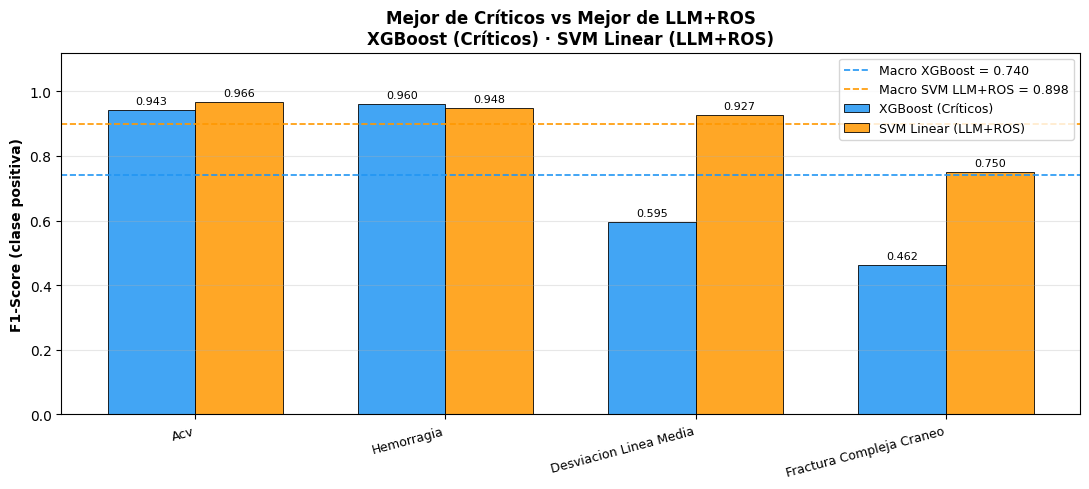

In [13]:
# =============================================================================
# COMPARACIÓN DIRECTA: XGBoost (Críticos) vs SVM Linear (LLM+ROS)
# Nota: test sets distintos — comparación orientativa entre mejores de cada grupo
# =============================================================================

f1_xgb_por_pat = {p: df_xgb_crit.loc[p, 'F1'] for p in PATOLOGIAS}
f1_svm_por_pat = {p: res_svm_llm[p]['F1']      for p in PATOLOGIAS}

filas = []
for p in PATOLOGIAS:
    fx = f1_xgb_por_pat[p]
    fs = f1_svm_por_pat[p]
    filas.append({
        'Patología':               p.replace('_', ' ').title(),
        'XGBoost (Críticos)':      round(fx, 3),
        'SVM Linear (LLM+ROS)':   round(fs, 3),
        'Δ (LLM+ROS − Críticos)': round(fs - fx, 3),
    })

df_best_vs = pd.DataFrame(filas).set_index('Patología')
df_best_vs.loc['Macro-avg'] = {
    'XGBoost (Críticos)':      round(f1_macro_xgb, 3),
    'SVM Linear (LLM+ROS)':   round(f1_macro_svm_llm, 3),
    'Δ (LLM+ROS − Críticos)': round(f1_macro_svm_llm - f1_macro_xgb, 3),
}

print('=' * 70)
print('COMPARACIÓN DIRECTA: XGBoost (Críticos) vs SVM Linear (LLM+ROS)')
print('(Nota: conjuntos de prueba distintos — comparación orientativa)')
print('=' * 70)
print(df_best_vs.to_string())

# --- Gráfico ---
etiquetas = [p.replace('_', ' ').title() for p in PATOLOGIAS]
x     = np.arange(len(etiquetas))
ancho = 0.35

fig, ax = plt.subplots(figsize=(11, 5))

bars1 = ax.bar(x - ancho/2, [f1_xgb_por_pat[p] for p in PATOLOGIAS],
               ancho, label='XGBoost (Críticos)',  color='#2196F3', alpha=0.85, edgecolor='black', lw=0.7)
bars2 = ax.bar(x + ancho/2, [f1_svm_por_pat[p] for p in PATOLOGIAS],
               ancho, label='SVM Linear (LLM+ROS)', color='#FF9800', alpha=0.85, edgecolor='black', lw=0.7)

ax.bar_label(bars1, fmt='%.3f', padding=3, fontsize=8)
ax.bar_label(bars2, fmt='%.3f', padding=3, fontsize=8)

ax.axhline(f1_macro_xgb,     color='#2196F3', linestyle='--', linewidth=1.2,
           label=f'Macro XGBoost = {f1_macro_xgb:.3f}')
ax.axhline(f1_macro_svm_llm, color='#FF9800', linestyle='--', linewidth=1.2,
           label=f'Macro SVM LLM+ROS = {f1_macro_svm_llm:.3f}')

ax.set_xticks(x)
ax.set_xticklabels(etiquetas, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('F1-Score (clase positiva)', fontweight='bold')
ax.set_title('Mejor de Críticos vs Mejor de LLM+ROS\nXGBoost (Críticos) · SVM Linear (LLM+ROS)',
             fontweight='bold')
ax.set_ylim(0, 1.12)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/comparacion_mejores_criticos_vs_llm.png', dpi=150, bbox_inches='tight')
plt.show()


## Conclusiones finales

### PARTE A — Críticos (sin augmentación, test: 191 muestras)

| Modelo | F1-Macro | Kappa-Macro | AUC-Macro |
|---|---|---|---|
| **XGBoost** | **~0.74** | **~0.66** | N/D |
| SVM Linear | ~0.67 | ~0.56 | N/D |
| LSTM Bidireccional | ~0.63 | ~0.45 | ~0.83 |

- **XGBoost** lidera en F1-macro y Kappa en el grupo críticos.
- **LSTM** sufre en patologías con muy pocos positivos en test: desviación línea media (12 casos) y fractura (2 casos), lo que hace las métricas muy inestables.
- SVM es competitivo en ACV y hemorragia pero cae con desbalance extremo.

### PARTE B — LLM+ROS (datos aumentados, test: 143 muestras)

| Modelo | F1-Macro | Kappa-Macro | AUC-Macro |
|---|---|---|---|
| **SVM Linear** | **~0.90** | N/D | N/D |
| **Random Forest** | **~0.89** | N/D | N/D |
| DistilBERT | ~0.74 | **~0.59** | **~0.92** |
| LSTM | ~0.69 | ~0.47 | ~0.85 |

- **SVM Linear y RF** lideran en F1-macro con el dataset LLM+ROS.
- **DistilBERT** es el mejor en Kappa y AUC — mayor calibración probabilística y capacidad discriminativa.
- LSTM mejora con LLM+ROS pero no supera a los modelos clásicos en F1.

### Impacto de la augmentación LLM+ROS

La augmentación es el factor más determinante, superando la complejidad del modelo:

| Patología | SVM Críticos → SVM LLM+ROS |
|---|---|
| desviacion_linea_media | 0.47 → **0.93** |
| fractura_compleja_craneo | 0.33 → **0.75** |
| acv | 0.93 → **0.97** |
| hemorragia | 0.94 → **0.95** |

### Recomendación final

> **SVM Linear con LLM+ROS** para producción: mejor F1-macro (0.90), simple, rápido y sin GPU.
>
> **DistilBERT** como complemento cuando se necesita calibración probabilística (mejor Kappa: 0.59, AUC: 0.92).
>
> **`fractura_compleja_craneo`** sigue siendo la limitación principal del sistema — solo 5 casos en el test set de 143 muestras.